# Corporate Bankruptcy Prediction

**Taiwan Economic Journal, 1999-2009 — 6,819 companies, 95 financial ratios, 3.23% bankruptcy rate**

## 1. Setup

In [1]:
# !pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn lightgbm xgboost shap joblib

In [2]:
# Imports and run configuration (seed, CV folds, search budget)
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    cross_val_score, cross_validate, cross_val_predict, RandomizedSearchCV,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    average_precision_score, roc_auc_score, brier_score_loss,
    precision_recall_curve, roc_curve, confusion_matrix,
    classification_report,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from scipy.stats import loguniform, randint, uniform

warnings.filterwarnings("ignore")

# ----------------------------------------------------------------------------
# CONFIG
# ----------------------------------------------------------------------------
SEED        = 42
TEST_SIZE   = 0.20
N_SPLITS    = 5
N_REPEATS   = 5      # repeated CV for the model shortlist
SEARCH_ITER = 100    # RandomizedSearchCV budget
N_JOBS      = -1
COST_FN     = 10     # cost of missing a bankruptcy, relative to a false alarm (=1)
TARGET      = "Bankrupt?"

np.random.seed(SEED)
sns.set_style("whitegrid")
sns.set_context("notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

OUT_DIR = Path("artifacts")
OUT_DIR.mkdir(exist_ok=True)

print("Setup complete. Seed =", SEED)

Setup complete. Seed = 42


### Helper functions

In [3]:
# Utility: sanitize column names for LightGBM; utility: run a model through CV and report scores
def clean_names(cols):
    """LightGBM rejects/warns on special characters in feature names."""
    out = []
    for c in cols:
        c = (str(c).strip()
             .replace(" ", "_").replace("/", "_per_").replace("%", "pct")
             .replace("(", "").replace(")", "").replace(",", "")
             .replace("\u00a5", "Y").replace("-", "_").replace(".", ""))
        while "__" in c:
            c = c.replace("__", "_")
        out.append(c.strip("_"))
    return out


def cv_report(name, estimator, X, y, cv, scoring=("average_precision", "roc_auc", "f1", "recall", "precision")):
    """Cross-validate and return a one-row summary dict."""
    res = cross_validate(estimator, X, y, cv=cv, scoring=list(scoring), n_jobs=N_JOBS)
    row = {"model": name}
    for s in scoring:
        row[s] = res[f"test_{s}"].mean()
        if s == "average_precision":
            row["ap_std"] = res[f"test_{s}"].std()
    return row


def optimal_threshold(y_true, y_prob, beta=1.0):
    """Threshold that maximises F-beta on a precision-recall curve."""
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    prec, rec = prec[:-1], rec[:-1]          # drop the trailing (1, 0) sentinel point
    denom = (beta ** 2) * prec + rec
    fbeta = np.where(denom > 0, (1 + beta ** 2) * prec * rec / np.maximum(denom, 1e-12), 0.0)
    i = int(np.nanargmax(fbeta))
    return float(thr[i]), float(fbeta[i]), float(prec[i]), float(rec[i])


def threshold_metrics(y_true, y_prob, threshold):
    """Confusion-matrix derived metrics at a given decision threshold."""
    pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "TP": int(tp), "FN": int(fn), "FP": int(fp), "TN": int(tn),
        "recall":    tp / max(tp + fn, 1),
        "precision": tp / max(tp + fp, 1),
        "f1":        2 * tp / max(2 * tp + fp + fn, 1),
        "f2":        5 * tp / max(5 * tp + 4 * fn + fp, 1),
        "specificity": tn / max(tn + fp, 1),
    }

print("Helpers defined.")

Helpers defined.


## 2. Load the data

In [4]:
# Locate and load the dataset
CANDIDATES = ["data.csv"]

DATA_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find the dataset. Set DATA_PATH manually to your data.csv path."
    )

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH}")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

Loaded data.csv
Shape: 6,819 rows x 96 columns


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,Continuous interest rate (after tax),Operating Expense Rate,Research and development expense rate,Cash flow rate,Interest-bearing debt interest rate,Tax rate (A),Net Value Per Share (B),Net Value Per Share (A),Net Value Per Share (C),Persistent EPS in the Last Four Seasons,Cash Flow Per Share,Revenue Per Share (Yuan ¥),Operating Profit Per Share (Yuan ¥),Per Share Net profit before tax (Yuan ¥),Realized Sales Gross Profit Growth Rate,Operating Profit Growth Rate,After-tax Net Profit Growth Rate,Regular Net Profit Growth Rate,Continuous Net Profit Growth Rate,Total Asset Growth Rate,Net Value Growth Rate,Total Asset Return Growth Rate Ratio,Cash Reinvestment %,Current Ratio,Quick Ratio,Interest Expense Ratio,Total debt/Total net worth,Debt ratio %,Net worth/Assets,Long-term fund suitability ratio (A),Borrowing dependency,Contingent liabilities/Net worth,Operating profit/Paid-in capital,Net profit before tax/Paid-in capital,Inventory and accounts receivable/Net value,Total Asset Turnover,Accounts Receivable Turnover,Average Collection Days,Inventory Turnover Rate (times),Fixed Assets Turnover Frequency,Net Worth Turnover Rate (times),Revenue per person,Operating profit per person,Allocation rate per person,Working Capital to Total Assets,Quick Assets/Total Assets,Current Assets/Total Assets,Cash/Total Assets,Quick Assets/Current Liability,Cash/Current Liability,Current Liability to Assets,Operating Funds to Liability,Inventory/Working Capital,Inventory/Current Liability,Current Liabilities/Liability,Working Capital/Equity,Current Liabilities/Equity,Long-term Liability to Current Assets,Retained Earnings to Total Assets,Total income/Total expense,Total expense/Assets,Current Asset Turnover Rate,Quick Asset Turnover Rate,Working capitcal Turnover Rate,Cash Turnover Rate,Cash Flow to Sales,Fixed Assets to Assets,Current Liability to Liability,Current Liability to Equity,Equity to Long-term Liability,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets,Cash Flow to Equity,Current Liability to Current Assets,Liability-Assets Flag,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,0.147950,0.147950,0.169141,0.311664,0.017560,0.095921,0.138736,0.022102,0.848195,0.688979,0.688979,0.217535,4.980000e+09,0.000327,0.263100,0.363725,0.002259,0.001208,0.629951,0.021266,0.207576,0.792424,0.005024,0.390284,0.006479,0.095885,0.137757,0.398036,0.086957,0.001814,0.003487,1.820926e-04,1.165007e-04,0.032903,0.034164,0.392913,0.037135,0.672775,0.166673,0.190643,0.004094,0.001997,1.473360e-04,0.147308,0.334015,0.276920,0.001036,0.676269,0.721275,0.339077,0.025592,0.903225,0.002022,0.064856,7.010000e+08,6.550000e+09,0.593831,4.580000e+08,0.671568,0.424206,0.676269,0.339077,0.126549,0.637555,0.458609,0.520382,0.312905,0.118250,0,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,2.897851e-04,0.0,0.461867,0.000647,0.0,0.182251,0.182251,0.182251,0.208944,0.318137,0.021144,0.093722,0.169918,0.022080,0.848088,0.689693,0.689702,0.217620,6.110000e+09,0.000443,0.264516,0.376709,0.006016,0.004039,0.635172,0.012502,0.171176,0.828824,0.005059,0.376760,0.005835,0.093743,0.168962,0.397725,0.064468,0.001286,0.004917,9.360000e+09,7.190000e+08,0.025484,0.0068

### Data profile

In [5]:
# Shape, missingness, duplicates, constant/binary columns
df_raw.columns = df_raw.columns.str.strip()   # source CSV has leading spaces in every header

n_rows, n_cols = df_raw.shape
n_missing = int(df_raw.isnull().sum().sum())
n_dupes = int(df_raw.duplicated().sum())
nunique = df_raw.nunique()
constant_cols = list(nunique[nunique == 1].index)
binary_cols = list(nunique[nunique == 2].index)

print(f"Rows                : {n_rows:,}")
print(f"Columns             : {n_cols}")
print(f"Missing values      : {n_missing}")
print(f"Duplicate rows      : {n_dupes}")
print(f"Constant columns    : {constant_cols}")
print(f"Binary columns      : {binary_cols}")
print(f"\nDtypes:\n{df_raw.dtypes.value_counts().to_string()}")

Rows                : 6,819
Columns             : 96
Missing values      : 0
Duplicate rows      : 0
Constant columns    : ['Net Income Flag']
Binary columns      : ['Bankrupt?', 'Liability-Assets Flag']

Dtypes:
float64    93
int64       3


In [6]:
# Class balance of the target
counts = df_raw[TARGET].value_counts().sort_index()
pct = df_raw[TARGET].value_counts(normalize=True).sort_index() * 100
imbalance_ratio = counts[0] / counts[1]

print(f"Healthy  (0): {counts[0]:,}  ({pct[0]:.2f}%)")
print(f"Bankrupt (1): {counts[1]:,}  ({pct[1]:.2f}%)")
print(f"Imbalance ratio: {imbalance_ratio:.1f} : 1")
print(f"\nMajority-class baseline accuracy: {pct[0]:.2f}%  <-- this is why accuracy is useless here")

Healthy  (0): 6,599  (96.77%)
Bankrupt (1): 220  (3.23%)
Imbalance ratio: 30.0 : 1

Majority-class baseline accuracy: 96.77%  <-- this is why accuracy is useless here


## 3. Exploratory analysis

### 3.1 Class distribution

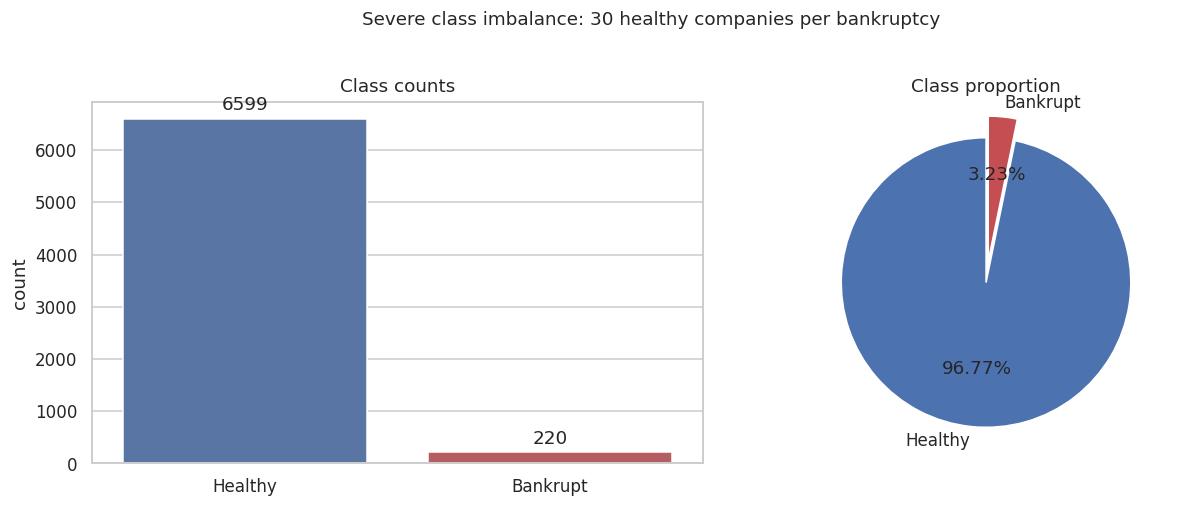

In [7]:
# Plot class counts and class balance
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x=TARGET, data=df_raw, hue=TARGET, palette=["#4C72B0", "#C44E52"],
              legend=False, ax=axes[0])
axes[0].set_title("Class counts")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Healthy", "Bankrupt"])
axes[0].set_xlabel("")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%d", padding=3)

axes[1].pie(counts.values, labels=["Healthy", "Bankrupt"], autopct="%1.2f%%",
            colors=["#4C72B0", "#C44E52"], explode=(0, 0.15), startangle=90)
axes[1].set_title("Class proportion")

plt.suptitle(f"Severe class imbalance: {imbalance_ratio:.0f} healthy companies per bankruptcy",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Which ratios separate the two classes?

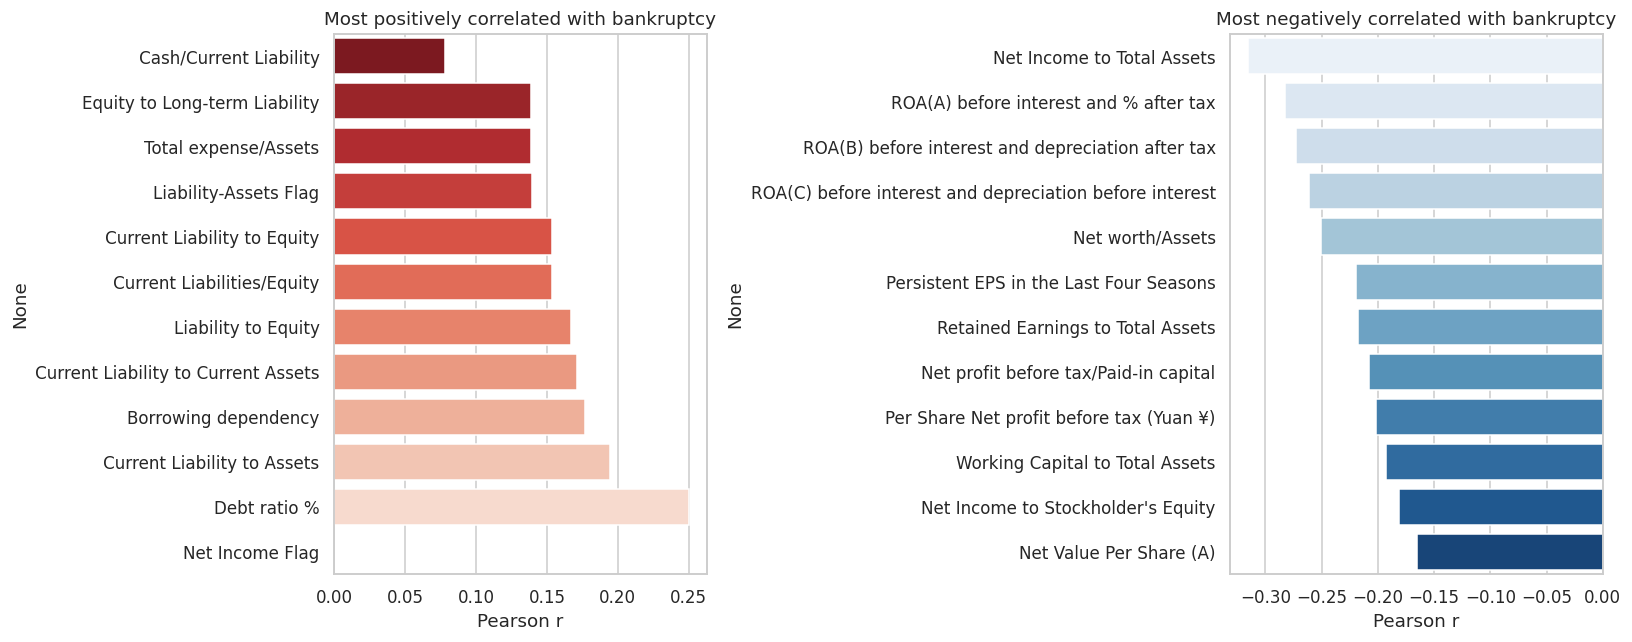

Strongest absolute correlations:
Net Income to Total Assets                                 0.3155
ROA(A) before interest and % after tax                     0.2829
ROA(B) before interest and depreciation after tax          0.2731
ROA(C) before interest and depreciation before interest    0.2608
Net worth/Assets                                           0.2502
Debt ratio %                                               0.2502
Persistent EPS in the Last Four Seasons                    0.2196
Retained Earnings to Total Assets                          0.2178
Net profit before tax/Paid-in capital                      0.2079
Per Share Net profit before tax (Yuan ¥)                   0.2014


In [8]:
# Correlation of each feature with the target
corr = df_raw.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()

top_neg = corr.head(12)   # lower value -> higher bankruptcy risk
top_pos = corr.tail(12)   # higher value -> higher bankruptcy risk

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=top_pos.values, y=top_pos.index, hue=top_pos.index,
            palette="Reds_r", legend=False, ax=axes[0])
axes[0].set_title("Most positively correlated with bankruptcy")
axes[0].set_xlabel("Pearson r")

sns.barplot(x=top_neg.values, y=top_neg.index, hue=top_neg.index,
            palette="Blues", legend=False, ax=axes[1])
axes[1].set_title("Most negatively correlated with bankruptcy")
axes[1].set_xlabel("Pearson r")

plt.tight_layout()
plt.show()

print("Strongest absolute correlations:")
print(corr.abs().sort_values(ascending=False).head(10).round(4).to_string())

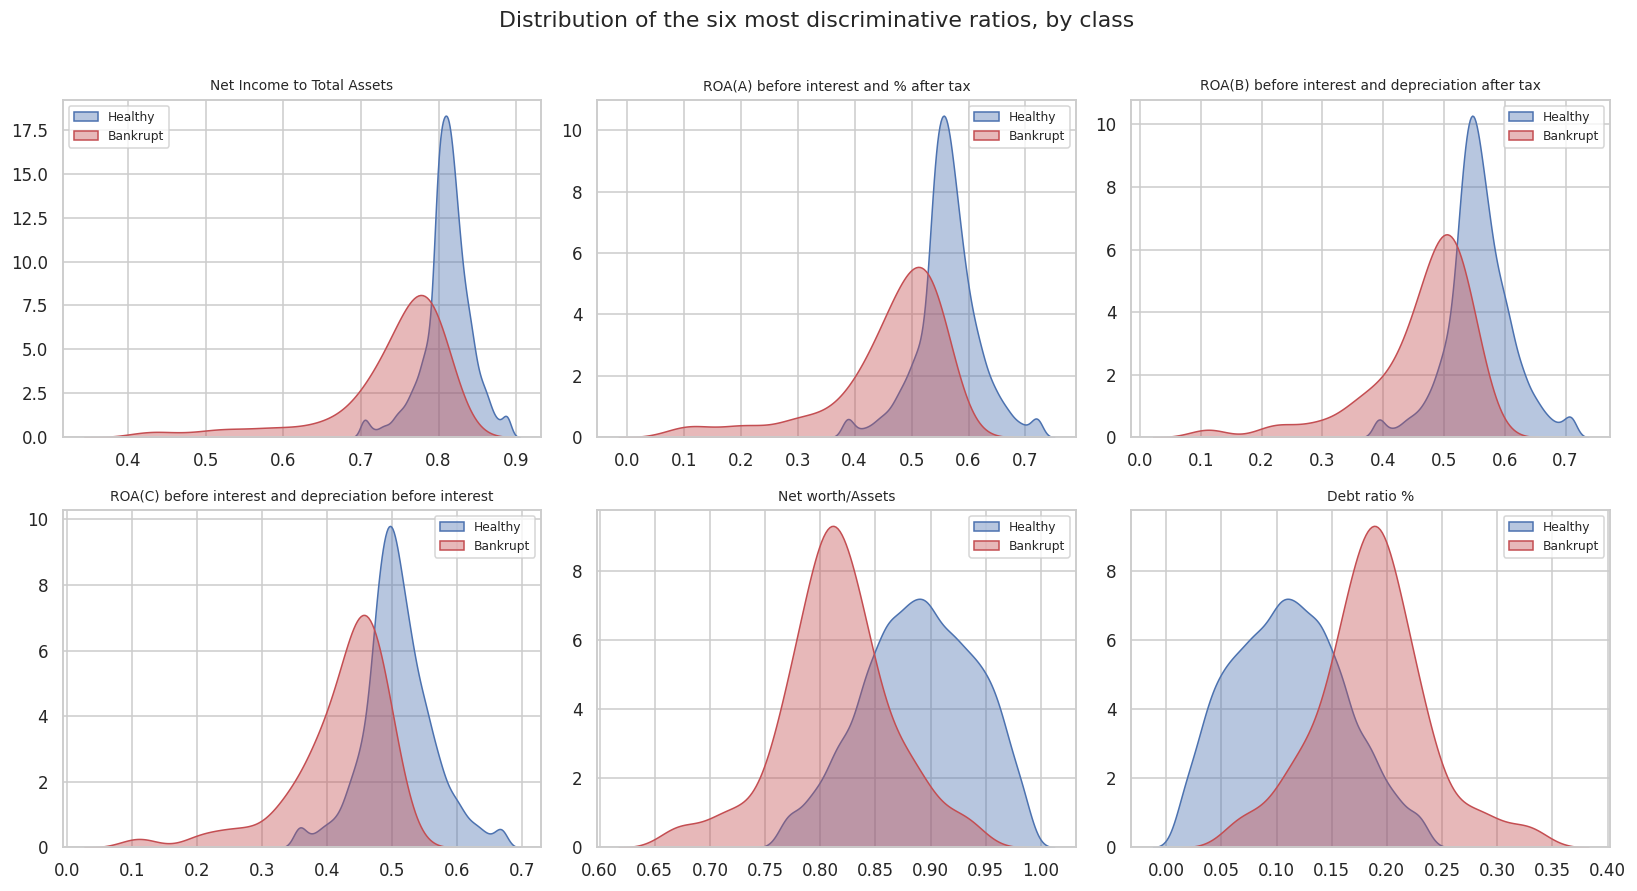

In [9]:
# Plot distributions of the most discriminative features by class
key_features = corr.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), key_features):
    for cls, colour, label in [(0, "#4C72B0", "Healthy"), (1, "#C44E52", "Bankrupt")]:
        vals = df_raw.loc[df_raw[TARGET] == cls, feat]
        lo, hi = vals.quantile([0.01, 0.99])
        sns.kdeplot(vals.clip(lo, hi), ax=ax, fill=True, alpha=0.4,
                    color=colour, label=label, warn_singular=False)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of the six most discriminative ratios, by class", y=1.01)
plt.tight_layout()
plt.show()

### 3.3 Multicollinearity

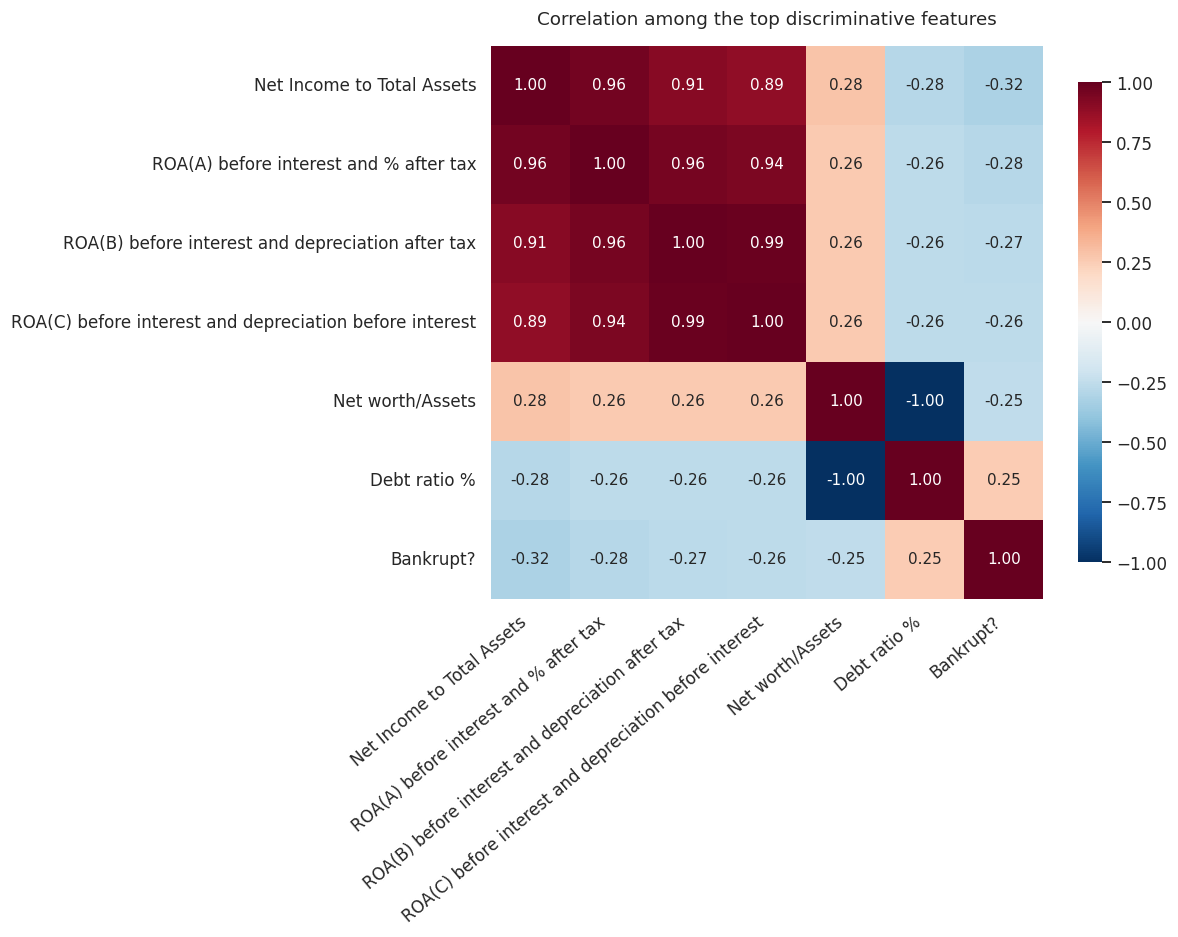

Feature pairs with |r| > 0.95: 23

Top 8 most redundant pairs:
Current Liabilities/Equity     Current Liability to Equity       1.0000
Current Liabilities/Liability  Current Liability to Liability    1.0000
Debt ratio %                   Net worth/Assets                  1.0000
Operating Gross Margin         Gross Profit to Sales             1.0000
Net Value Per Share (A)        Net Value Per Share (C)           0.9998
Operating Gross Margin         Realized Sales Gross Margin       0.9995
Realized Sales Gross Margin    Gross Profit to Sales             0.9995
Net Value Per Share (B)        Net Value Per Share (A)           0.9993


In [10]:
# Correlation among the top features to check for redundancy
sub = df_raw[key_features + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(sub, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 10}, ax=ax)
ax.set_title("Correlation among the top discriminative features", pad=14)
plt.setp(ax.get_xticklabels(), rotation=40, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

upper = df_raw.drop(columns=[TARGET]).corr().abs()
mask = np.triu(np.ones(upper.shape), k=1).astype(bool)
pairs = upper.where(mask).stack().sort_values(ascending=False)
print(f"Feature pairs with |r| > 0.95: {(pairs > 0.95).sum()}")
print("\nTop 8 most redundant pairs:")
print(pairs.head(8).round(4).to_string())


## 4. Cleaning

In [11]:
# Drop the constant column and duplicate rows
df = df_raw.copy()

before = df.shape[1]
df = df.drop(columns=constant_cols)
print(f"Dropped {before - df.shape[1]} constant column(s): {constant_cols}")

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate row(s)")

before = len(df)
df.dropna(inplace=True)
print(f"Dropped {before - len(df)} row(s) with missing values")

assert df.isnull().sum().sum() == 0, "Unexpected missing values"

FEATURE_NAMES_ORIGINAL = [c for c in df.columns if c != TARGET]
df.columns = clean_names(df.columns)
TARGET_CLEAN = clean_names([TARGET])[0]

print(f"\nFinal shape: {df.shape[0]:,} x {df.shape[1]}")
print(f"Target column: '{TARGET_CLEAN}'")

Dropped 1 constant column(s): ['Net Income Flag']
Dropped 0 duplicate row(s)
Dropped 0 row(s) with missing values

Final shape: 6,819 x 95
Target column: 'Bankrupt?'


## 5. Train / test split

In [12]:
# Stratified train/test split; test set untouched until Section 12
X = df.drop(columns=[TARGET_CLEAN])
y = df[TARGET_CLEAN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Train: {X_train.shape[0]:,} rows, {int(y_train.sum())} bankruptcies ({y_train.mean()*100:.2f}%)")
print(f"Test : {X_test.shape[0]:,} rows, {int(y_test.sum())} bankruptcies ({y_test.mean()*100:.2f}%)")
print(f"Features: {X_train.shape[1]}")
print(f"\nscale_pos_weight = {scale_pos_weight:.2f}")
print(f"\nOnly {int(y_train.sum())} positive examples to learn from. This is the binding")
print("constraint on the whole project -- it limits how much hyperparameter tuning can help.")

Train: 5,455 rows, 176 bankruptcies (3.23%)
Test : 1,364 rows, 44 bankruptcies (3.23%)
Features: 94

scale_pos_weight = 29.99

Only 176 positive examples to learn from. This is the binding
constraint on the whole project -- it limits how much hyperparameter tuning can help.


## 6. Baselines

In [13]:
# Dummy and logistic-regression baselines under stratified CV
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

baselines = {
    "Dummy (stratified)": DummyClassifier(strategy="stratified", random_state=SEED),
    "Dummy (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=SEED)),
    ]),
    "Logistic Regression (balanced)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ]),
}

baseline_rows = [cv_report(n, m, X_train, y_train, cv) for n, m in baselines.items()]
baseline_df = pd.DataFrame(baseline_rows).set_index("model")
display(baseline_df.round(4))

print(f"\nClass prevalence (theoretical dummy AP): {y_train.mean():.4f}")
print("Note the 'most frequent' dummy scores ~0.97 accuracy while being useless --")
print("its recall on the positive class is 0.")

,average_precision,ap_std,roc_auc,f1,recall,precision
model,,,,,,
Dummy (stratified),0.0325,0.0006,0.4956,0.0231,0.0227,0.0235
Dummy (most frequent),0.0323,0.0004,0.5000,0.0000,0.0000,0.0000
Logistic Regression,0.3560,0.0300,0.8980,0.2973,0.2160,0.4849
Logistic Regression (balanced),0.3269,0.0421,0.8861,0.2782,0.7613,0.1706



Class prevalence (theoretical dummy AP): 0.0323
Note the 'most frequent' dummy scores ~0.97 accuracy while being useless --
its recall on the positive class is 0.


## 7. Handling class imbalance — compared properly

In [14]:
# Define candidate imbalance-handling strategies, each inside an imblearn Pipeline
def lgbm(**kw):
    p = dict(n_estimators=400, learning_rate=0.05, num_leaves=31,
             random_state=SEED, n_jobs=1, verbose=-1)
    p.update(kw)
    return LGBMClassifier(**p)

strategies = {
    "None (raw)":            lgbm(),
    "Class weights":         lgbm(class_weight="balanced"),
    "SMOTE":                 ImbPipeline([("res", SMOTE(random_state=SEED)), ("clf", lgbm())]),
    "BorderlineSMOTE":       ImbPipeline([("res", BorderlineSMOTE(random_state=SEED)), ("clf", lgbm())]),
    "ADASYN":                ImbPipeline([("res", ADASYN(random_state=SEED)), ("clf", lgbm())]),
    "SMOTETomek":            ImbPipeline([("res", SMOTETomek(random_state=SEED)), ("clf", lgbm())]),
    "Random undersampling":  ImbPipeline([("res", RandomUnderSampler(random_state=SEED)), ("clf", lgbm())]),
    "SMOTE 0.3 + weights":   ImbPipeline([("res", SMOTE(sampling_strategy=0.3, random_state=SEED)),
                                          ("clf", lgbm(class_weight="balanced"))]),
}

rows = [cv_report(n, m, X_train, y_train, cv) for n, m in strategies.items()]
strategy_df = (pd.DataFrame(rows)
               .set_index("model")
               .sort_values("average_precision", ascending=False))
display(strategy_df.round(4))

,average_precision,ap_std,roc_auc,f1,recall,precision
model,,,,,,
Class weights,0.4875,0.0662,0.9380,0.4322,0.3292,0.6337
BorderlineSMOTE,0.4861,0.0566,0.9327,0.4532,0.3976,0.5362
None (raw),0.4819,0.0655,0.9437,0.3294,0.2270,0.6234
SMOTETomek,0.4737,0.0386,0.9349,0.4620,0.4432,0.4864
SMOTE 0.3 + weights,0.4704,0.0722,0.9349,0.4617,0.4260,0.5061
SMOTE,0.4666,0.0470,0.9346,0.4457,0.4203,0.4792
ADASYN,0.4649,0.0460,0.9342,0.4491,0.4144,0.4981
Random undersampling,0.3790,0.0676,0.9226,0.2744,0.8524,0.1639


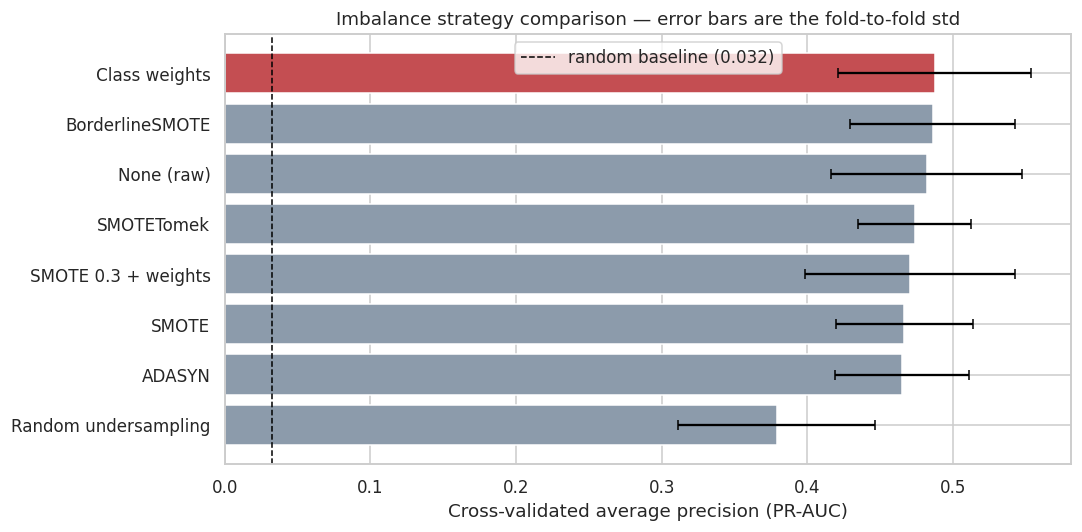

In [15]:
# Plot the imbalance-strategy comparison
fig, ax = plt.subplots(figsize=(10, 5))
s = strategy_df["average_precision"].sort_values()
colors = ["#C44E52" if v == s.max() else "#8C9BAB" for v in s.values]
ax.barh(s.index, s.values, color=colors,
        xerr=strategy_df.loc[s.index, "ap_std"], capsize=3)
ax.axvline(y_train.mean(), color="black", ls="--", lw=1,
           label=f"random baseline ({y_train.mean():.3f})")
ax.set_xlabel("Cross-validated average precision (PR-AUC)")
ax.set_title("Imbalance strategy comparison — error bars are the fold-to-fold std")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Model comparison

In [16]:
# Repeated stratified CV comparison of candidate models
rcv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)

candidates = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2, random_state=SEED, n_jobs=1),
    "Random Forest (balanced)": RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2, class_weight="balanced_subsample",
        random_state=SEED, n_jobs=1),
    "XGBoost": XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.8,
        colsample_bytree=0.8, eval_metric="aucpr", random_state=SEED, n_jobs=1),
    "XGBoost (scale_pos_weight)": XGBClassifier(
        n_estimators=400, learning_rate=0.05, max_depth=4, subsample=0.8,
        colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
        eval_metric="aucpr", random_state=SEED, n_jobs=1),
    "LightGBM": lgbm(),
    "LightGBM (balanced)": lgbm(class_weight="balanced"),
}

model_rows = []
for name, model in candidates.items():
    scores = cross_val_score(model, X_train, y_train, cv=rcv,
                             scoring="average_precision", n_jobs=N_JOBS)
    model_rows.append({
        "model": name,
        "AP_mean": scores.mean(),
        "AP_std": scores.std(),
        "AP_min": scores.min(),
        "AP_max": scores.max(),
    })
    print(f"{name:30s} AP = {scores.mean():.4f} +/- {scores.std():.4f}")

model_df = pd.DataFrame(model_rows).set_index("model").sort_values("AP_mean", ascending=False)
display(model_df.round(4))

Logistic Regression            AP = 0.3292 +/- 0.0547
Random Forest                  AP = 0.4344 +/- 0.0665
Random Forest (balanced)       AP = 0.4063 +/- 0.0781
XGBoost                        AP = 0.4359 +/- 0.0821
XGBoost (scale_pos_weight)     AP = 0.4282 +/- 0.0853
LightGBM                       AP = 0.4682 +/- 0.0782
LightGBM (balanced)            AP = 0.4716 +/- 0.0819


,AP_mean,AP_std,AP_min,AP_max
model,,,,
LightGBM (balanced),0.4716,0.0819,0.3352,0.6509
LightGBM,0.4682,0.0782,0.3485,0.6701
XGBoost,0.4359,0.0821,0.3173,0.6496
Random Forest,0.4344,0.0665,0.3239,0.5561
XGBoost (scale_pos_weight),0.4282,0.0853,0.2899,0.6928
Random Forest (balanced),0.4063,0.0781,0.2783,0.6191
Logistic Regression,0.3292,0.0547,0.2143,0.4263


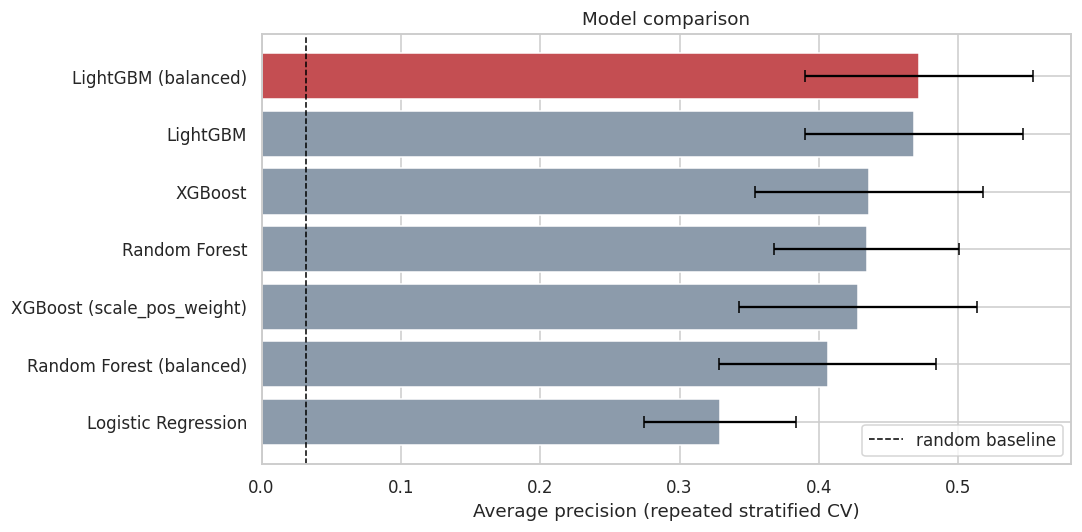

Best by CV average precision: LightGBM (balanced)  (AP = 0.4716)


In [17]:
# Plot the model comparison and pick the CV winner
fig, ax = plt.subplots(figsize=(10, 5))
m = model_df.sort_values("AP_mean")
ax.barh(m.index, m["AP_mean"], xerr=m["AP_std"], capsize=4,
        color=["#C44E52" if v == m["AP_mean"].max() else "#8C9BAB" for v in m["AP_mean"]])
ax.axvline(y_train.mean(), color="black", ls="--", lw=1, label="random baseline")
ax.set_xlabel("Average precision (repeated stratified CV)")
ax.set_title("Model comparison")
ax.legend()
plt.tight_layout()
plt.show()

BEST_MODEL_NAME = model_df.index[0]
BASELINE_AP = model_df.iloc[0]["AP_mean"]
print(f"Best by CV average precision: {BEST_MODEL_NAME}  (AP = {BASELINE_AP:.4f})")

## 9. Hyperparameter tuning

In [18]:
# Randomized hyperparameter search for LightGBM, scored on average precision
param_dist = {
    "n_estimators":     randint(150, 600),
    "learning_rate":    loguniform(0.01, 0.2),
    "num_leaves":       randint(7, 50),
    "max_depth":        [-1, 3, 4, 5, 6, 8],
    "min_child_samples": randint(5, 60),
    "subsample":        uniform(0.6, 0.4),
    "subsample_freq":   [1],
    "colsample_bytree": uniform(0.4, 0.6),
    "reg_lambda":       loguniform(1e-3, 50),
    "reg_alpha":        loguniform(1e-3, 10),
    "scale_pos_weight": [1, 5, 15, 30],
}

search = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=SEED, n_jobs=1, verbose=-1),
    param_distributions=param_dist,
    n_iter=SEARCH_ITER,
    scoring="average_precision",
    cv=StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED),
    n_jobs=N_JOBS,
    random_state=SEED,
    refit=False,
    verbose=0,
)
search.fit(X_train, y_train)

print(f"Best CV average precision: {search.best_score_:.4f}")
print("\nBest parameters:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:20s} {v}")

Best CV average precision: 0.4779

Best parameters:
  colsample_bytree     0.7942667971001001
  learning_rate        0.03688276822772607
  max_depth            6
  min_child_samples    59
  n_estimators         225
  num_leaves           32
  reg_alpha            0.026539376439360548
  reg_lambda           3.639956059264084
  scale_pos_weight     1
  subsample            0.7367518666865607
  subsample_freq       1


In [19]:
# Re-score the tuned configuration under the SAME repeated CV used in Section 8,
# so the comparison against the untuned baseline is apples-to-apples.
tuned_model = LGBMClassifier(random_state=SEED, n_jobs=1, verbose=-1, **search.best_params_)
tuned_scores = cross_val_score(tuned_model, X_train, y_train, cv=rcv,
                               scoring="average_precision", n_jobs=N_JOBS)

print(f"Untuned baseline ({BEST_MODEL_NAME}): {BASELINE_AP:.4f}")
print(f"Tuned LightGBM                      : {tuned_scores.mean():.4f} +/- {tuned_scores.std():.4f}")

if tuned_scores.mean() > BASELINE_AP:
    FINAL_BASE = tuned_model
    FINAL_LABEL = "Tuned LightGBM"
else:
    FINAL_BASE = candidates[BEST_MODEL_NAME]
    FINAL_LABEL = BEST_MODEL_NAME

print(f"\nSelected: {FINAL_LABEL}")


Untuned baseline (LightGBM (balanced)): 0.4716
Tuned LightGBM                      : 0.4445 +/- 0.0811

Selected: LightGBM (balanced)


## 10. Probability calibration

In [20]:
# Score the calibrated vs. uncalibrated model via out-of-fold predictions
uncalibrated = FINAL_BASE
calibrated = CalibratedClassifierCV(FINAL_BASE, method="sigmoid", cv=5)

cal_cv = StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED)
oof_uncal = cross_val_predict(uncalibrated, X_train, y_train, cv=cal_cv,
                              method="predict_proba", n_jobs=N_JOBS)[:, 1]
oof_cal = cross_val_predict(calibrated, X_train, y_train, cv=cal_cv,
                            method="predict_proba", n_jobs=N_JOBS)[:, 1]

print(f"{'':24s} {'AP':>8s} {'ROC-AUC':>9s} {'Brier':>8s}")
for label, p in [("Uncalibrated", oof_uncal), ("Calibrated (sigmoid)", oof_cal)]:
    print(f"{label:24s} {average_precision_score(y_train, p):8.4f} "
          f"{roc_auc_score(y_train, p):9.4f} {brier_score_loss(y_train, p):8.4f}")

                               AP   ROC-AUC    Brier
Uncalibrated               0.4751    0.9368   0.0254
Calibrated (sigmoid)       0.4208    0.8403   0.0249


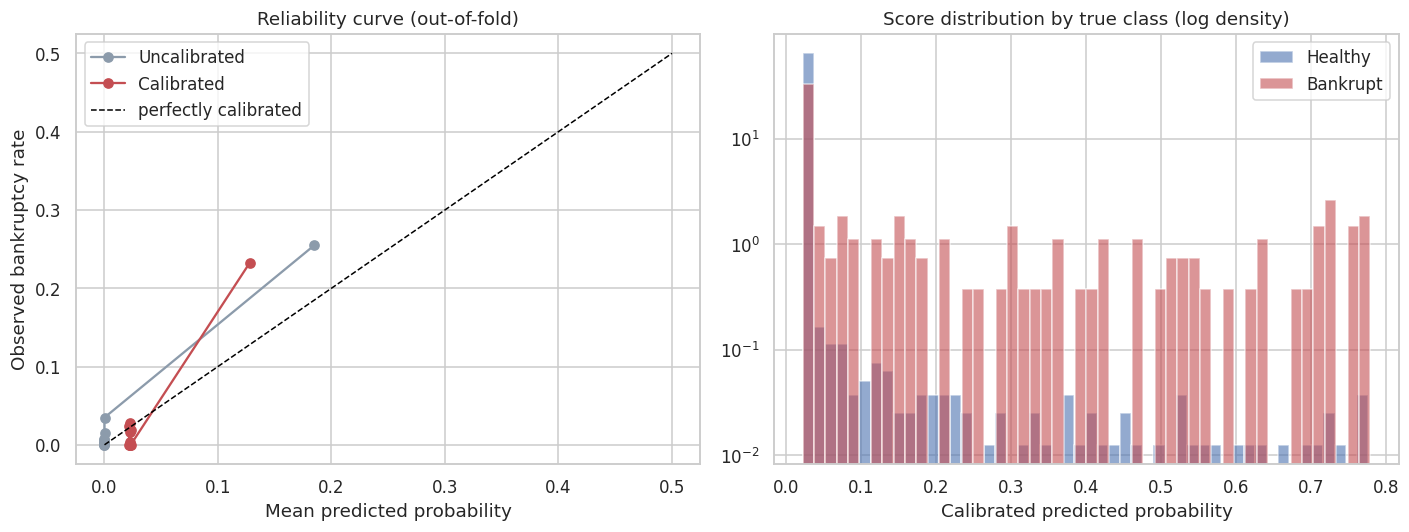

In [21]:
# Plot reliability curves before and after calibration
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for label, p, colour in [("Uncalibrated", oof_uncal, "#8C9BAB"),
                         ("Calibrated", oof_cal, "#C44E52")]:
    frac_pos, mean_pred = calibration_curve(y_train, p, n_bins=10, strategy="quantile")
    axes[0].plot(mean_pred, frac_pos, "o-", label=label, color=colour)
axes[0].plot([0, 0.5], [0, 0.5], "k--", lw=1, label="perfectly calibrated")
axes[0].set_xlabel("Mean predicted probability")
axes[0].set_ylabel("Observed bankruptcy rate")
axes[0].set_title("Reliability curve (out-of-fold)")
axes[0].legend()

axes[1].hist(oof_cal[y_train == 0], bins=50, alpha=0.6, label="Healthy",
             color="#4C72B0", density=True)
axes[1].hist(oof_cal[y_train == 1], bins=50, alpha=0.6, label="Bankrupt",
             color="#C44E52", density=True)
axes[1].set_yscale("log")
axes[1].set_xlabel("Calibrated predicted probability")
axes[1].set_title("Score distribution by true class (log density)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Choosing the decision threshold

In [22]:
# Select an F-beta-optimal decision threshold from out-of-fold predictions
def select_threshold(estimator, X, y, beta=2.0, repeats=3):
    """Median F-beta-optimal threshold across several independent CV fold assignments."""
    thresholds, oof_stack = [], []
    for r in range(repeats):
        folds = StratifiedKFold(N_SPLITS, shuffle=True, random_state=100 + r)
        oof = cross_val_predict(estimator, X, y, cv=folds,
                                method="predict_proba", n_jobs=N_JOBS)[:, 1]
        thr, _, _, _ = optimal_threshold(y, oof, beta=beta)
        thresholds.append(thr)
        oof_stack.append(oof)
    return float(np.median(thresholds)), thresholds, np.mean(oof_stack, axis=0)

THRESHOLD_F2, thr_runs, oof_final = select_threshold(calibrated, X_train, y_train, beta=2.0)
THRESHOLD_F1, _, _, _ = optimal_threshold(y_train, oof_final, beta=1.0)

print(f"F2-optimal threshold per repeat : {[round(t, 4) for t in thr_runs]}")
print(f"Median (used)                   : {THRESHOLD_F2:.4f}")
print(f"F1-optimal threshold            : {THRESHOLD_F1:.4f}")
print(f"Default                         : 0.5000")
print(f"\nSpread across repeats: {max(thr_runs) - min(thr_runs):.4f}  (small = stable)")

F2-optimal threshold per repeat : [0.0233, 0.024, 0.0243]
Median (used)                   : 0.0240
F1-optimal threshold            : 0.0291
Default                         : 0.5000

Spread across repeats: 0.0010  (small = stable)


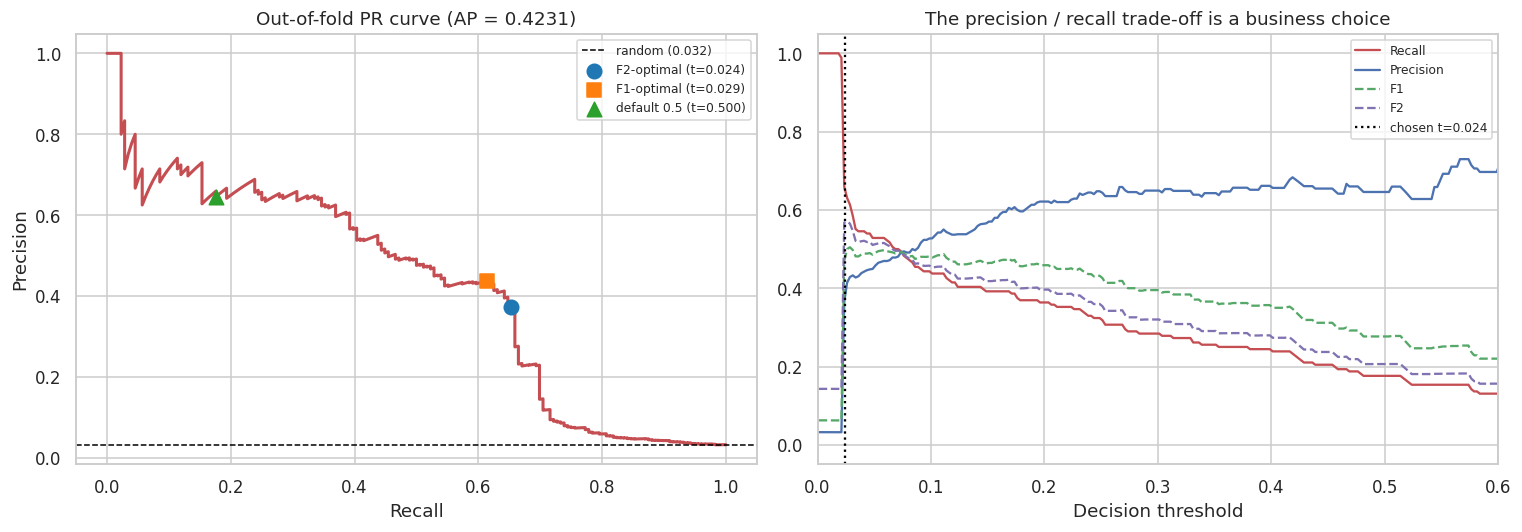

In [23]:
# Plot the precision-recall curve with the candidate thresholds marked
prec, rec, thr = precision_recall_curve(y_train, oof_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rec, prec, color="#C44E52", lw=2)
axes[0].axhline(y_train.mean(), color="black", ls="--", lw=1,
                label=f"random ({y_train.mean():.3f})")
for t, name, mk in [(THRESHOLD_F2, "F2-optimal", "o"), (THRESHOLD_F1, "F1-optimal", "s"), (0.5, "default 0.5", "^")]:
    m = threshold_metrics(y_train, oof_final, t)
    axes[0].scatter(m["recall"], m["precision"], s=90, marker=mk, zorder=5,
                    label=f"{name} (t={t:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title(f"Out-of-fold PR curve (AP = {average_precision_score(y_train, oof_final):.4f})")
axes[0].legend(fontsize=8)

grid = np.linspace(0.001, 0.999, 400)
f1s = [threshold_metrics(y_train, oof_final, t)["f1"] for t in grid]
f2s = [threshold_metrics(y_train, oof_final, t)["f2"] for t in grid]
recs = [threshold_metrics(y_train, oof_final, t)["recall"] for t in grid]
precs = [threshold_metrics(y_train, oof_final, t)["precision"] for t in grid]
axes[1].plot(grid, recs, label="Recall", color="#C44E52")
axes[1].plot(grid, precs, label="Precision", color="#4C72B0")
axes[1].plot(grid, f1s, label="F1", color="#55A868", ls="--")
axes[1].plot(grid, f2s, label="F2", color="#8172B2", ls="--")
axes[1].axvline(THRESHOLD_F2, color="black", ls=":", lw=1.5, label=f"chosen t={THRESHOLD_F2:.3f}")
axes[1].set_xlim(0, 0.6)
axes[1].set_xlabel("Decision threshold")
axes[1].set_title("The precision / recall trade-off is a business choice")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Expected-cost view

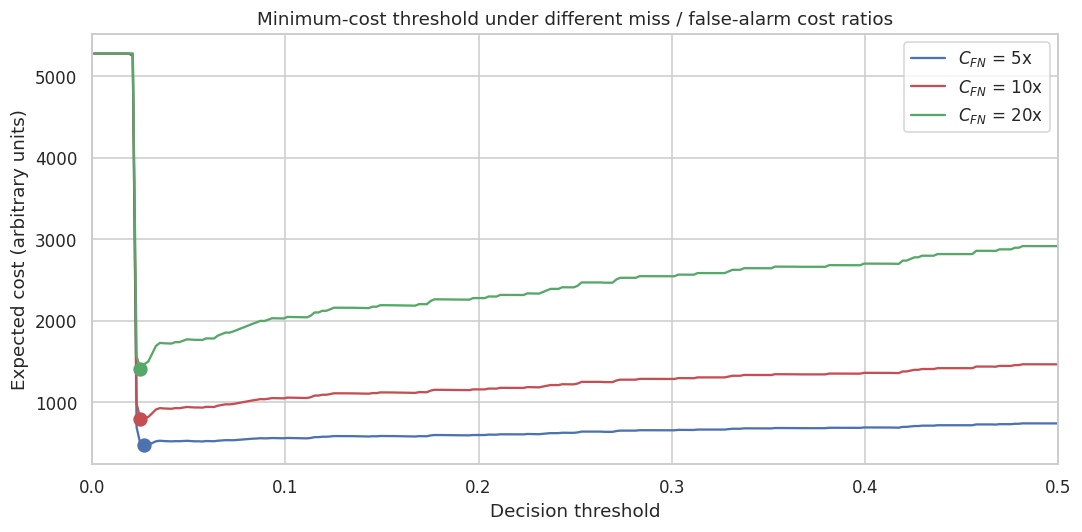

,cost_ratio,threshold,expected_cost,recall,precision,FN,FP
0,5:1,0.027,479,0.625,0.425,66,149
1,10:1,0.025,794,0.648,0.396,62,174
2,20:1,0.025,1414,0.648,0.396,62,174



Cost-optimal threshold at 10:1 -> 0.0250
As the cost of a miss rises, the optimal threshold falls and the model
becomes deliberately more trigger-happy. That is the correct behaviour.


In [24]:
# Sweep expected cost across a range of thresholds and cost ratios
grid = np.linspace(0.001, 0.8, 400)
fig, ax = plt.subplots(figsize=(10, 5))
cost_table = []

for c_fn, colour in zip([5, 10, 20], ["#4C72B0", "#C44E52", "#55A868"]):
    costs = []
    for t in grid:
        m = threshold_metrics(y_train, oof_final, t)
        costs.append(c_fn * m["FN"] + 1 * m["FP"])
    costs = np.array(costs)
    i = int(np.argmin(costs))
    ax.plot(grid, costs, color=colour, label=f"$C_{{FN}}$ = {c_fn}x")
    ax.scatter(grid[i], costs[i], color=colour, s=70, zorder=5)
    m = threshold_metrics(y_train, oof_final, grid[i])
    cost_table.append({"cost_ratio": f"{c_fn}:1", "threshold": round(grid[i], 4),
                       "expected_cost": int(costs[i]), "recall": round(m["recall"], 3),
                       "precision": round(m["precision"], 3),
                       "FN": m["FN"], "FP": m["FP"]})

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Expected cost (arbitrary units)")
ax.set_title("Minimum-cost threshold under different miss / false-alarm cost ratios")
ax.set_xlim(0, 0.5)
ax.legend()
plt.tight_layout()
plt.show()

display(pd.DataFrame(cost_table))

THRESHOLD_COST = cost_table[[r["cost_ratio"] for r in cost_table].index(f"{COST_FN}:1")]["threshold"]
print(f"\nCost-optimal threshold at {COST_FN}:1 -> {THRESHOLD_COST:.4f}")
print("As the cost of a miss rises, the optimal threshold falls and the model")
print("becomes deliberately more trigger-happy. That is the correct behaviour.")

## 12. Final evaluation on the held-out test set

In [25]:
# Fit the final calibrated model and score the held-out test set once
final_model = CalibratedClassifierCV(FINAL_BASE, method="sigmoid", cv=5)
final_model.fit(X_train, y_train)

y_prob = final_model.predict_proba(X_test)[:, 1]

test_ap    = average_precision_score(y_test, y_prob)
test_auc   = roc_auc_score(y_test, y_prob)
test_brier = brier_score_loss(y_test, y_prob)

print("=" * 62)
print("THRESHOLD-FREE METRICS  (test set, n = {:,})".format(len(y_test)))
print("=" * 62)
print(f"Average precision (PR-AUC) : {test_ap:.4f}   (random = {y_test.mean():.4f})")
print(f"ROC-AUC                    : {test_auc:.4f}")
print(f"Brier score                : {test_brier:.4f}   (lower is better)")
print(f"\nLift over random: {test_ap / y_test.mean():.1f}x")

THRESHOLD-FREE METRICS  (test set, n = 1,364)
Average precision (PR-AUC) : 0.5648   (random = 0.0323)
ROC-AUC                    : 0.9623
Brier score                : 0.0218   (lower is better)

Lift over random: 17.5x


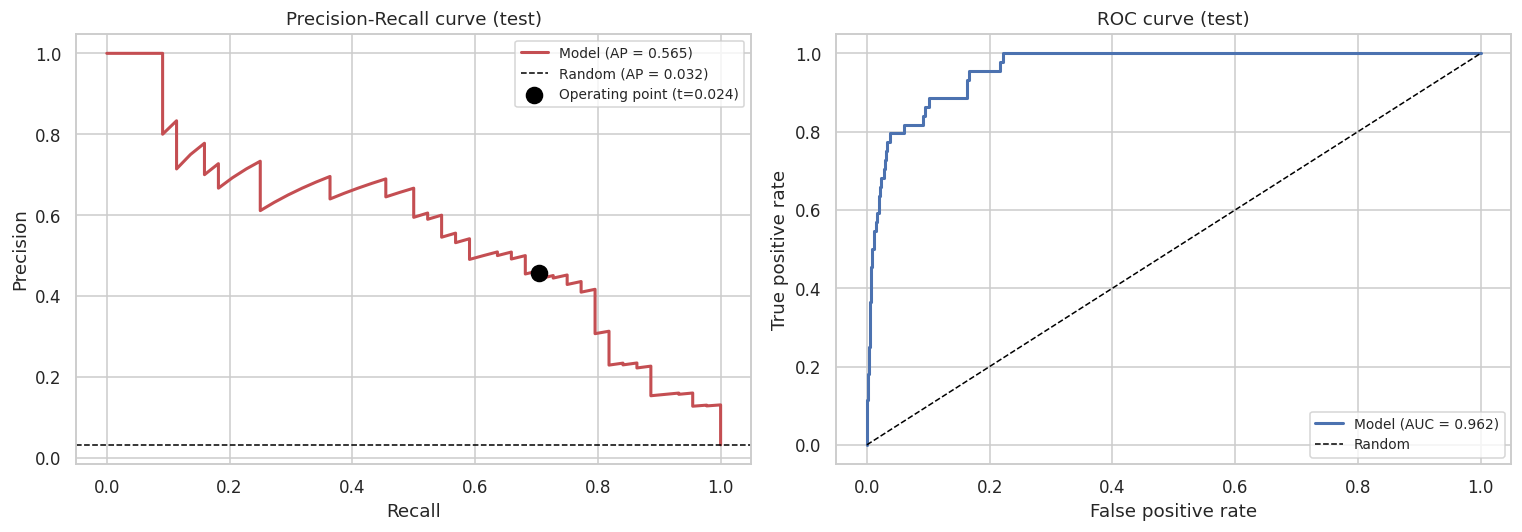

In [26]:
# Plot test-set PR curve, ROC curve, and calibration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p_t, r_t, _ = precision_recall_curve(y_test, y_prob)
axes[0].plot(r_t, p_t, color="#C44E52", lw=2, label=f"Model (AP = {test_ap:.3f})")
axes[0].axhline(y_test.mean(), color="black", ls="--", lw=1,
                label=f"Random (AP = {y_test.mean():.3f})")
m_sel = threshold_metrics(y_test, y_prob, THRESHOLD_F2)
axes[0].scatter(m_sel["recall"], m_sel["precision"], s=110, color="black", zorder=5,
                label=f"Operating point (t={THRESHOLD_F2:.3f})")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall curve (test)")
axes[0].legend(fontsize=9)

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#4C72B0", lw=2, label=f"Model (AUC = {test_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Random")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curve (test)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [27]:
# Metrics at each candidate operating threshold
operating_points = {
    "Default (0.50)":            0.50,
    f"F1-optimal ({THRESHOLD_F1:.3f})":   THRESHOLD_F1,
    f"F2-optimal ({THRESHOLD_F2:.3f})":   THRESHOLD_F2,
    f"Cost-optimal ({THRESHOLD_COST:.3f})": THRESHOLD_COST,
}

rows = []
for name, t in operating_points.items():
    m = threshold_metrics(y_test, y_prob, t)
    m["operating point"] = name
    m["expected_cost"] = COST_FN * m["FN"] + m["FP"]
    rows.append(m)

op_df = (pd.DataFrame(rows)
         .set_index("operating point")
         [["threshold", "TP", "FN", "FP", "TN", "recall", "precision", "f1", "f2", "expected_cost"]])
display(op_df.round(4))

print("\nMoving from the default cut-off to the tuned one changes nothing about the model --")
print("same weights, same probabilities. Only the cut-off moves. That alone takes recall")
print(f"from {op_df.loc['Default (0.50)', 'recall']:.1%} to {op_df.iloc[2]['recall']:.1%}.")

,threshold,TP,FN,FP,TN,recall,precision,f1,f2,expected_cost
operating point,,,,,,,,,,
Default (0.50),0.5000,14,30,7,1313,0.3182,0.6667,0.4308,0.3553,307
F1-optimal (0.029),0.0291,28,16,27,1293,0.6364,0.5091,0.5657,0.6061,187
F2-optimal (0.024),0.0240,31,13,37,1283,0.7045,0.4559,0.5536,0.6352,167
Cost-optimal (0.025),0.0250,30,14,33,1287,0.6818,0.4762,0.5607,0.6276,173



Moving from the default cut-off to the tuned one changes nothing about the model --
same weights, same probabilities. Only the cut-off moves. That alone takes recall
from 31.8% to 70.5%.


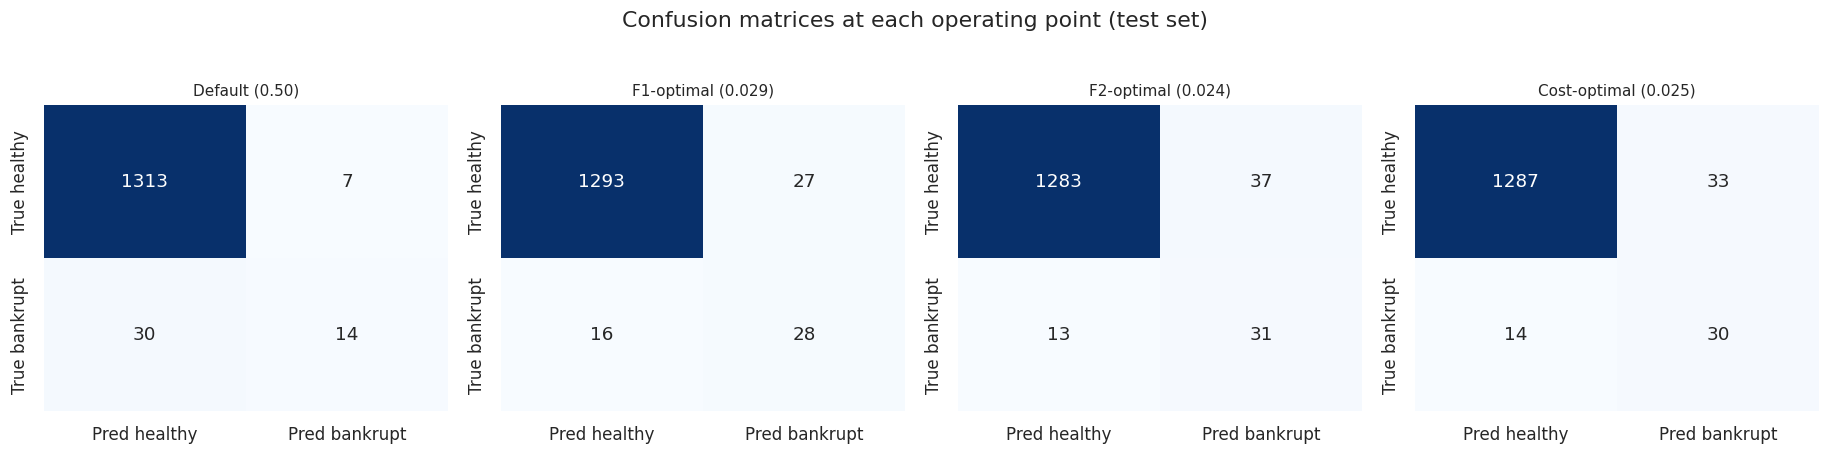

In [28]:
# Confusion matrices at each candidate threshold
fig, axes = plt.subplots(1, len(operating_points), figsize=(4.2 * len(operating_points), 4))
for ax, (name, t) in zip(np.atleast_1d(axes), operating_points.items()):
    cm = confusion_matrix(y_test, (y_prob >= t).astype(int), labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred healthy", "Pred bankrupt"],
                yticklabels=["True healthy", "True bankrupt"])
    ax.set_title(name, fontsize=10)
plt.suptitle("Confusion matrices at each operating point (test set)", y=1.03)
plt.tight_layout()
plt.show()

In [29]:
# Final classification report at the selected threshold
SELECTED_THRESHOLD = THRESHOLD_F2
y_pred = (y_prob >= SELECTED_THRESHOLD).astype(int)

print(f"FINAL MODEL: {FINAL_LABEL} + Platt calibration")
print(f"Decision threshold: {SELECTED_THRESHOLD:.4f}\n")
print(classification_report(y_test, y_pred, digits=3,
                            target_names=["Healthy", "Bankrupt"]))

FINAL MODEL: LightGBM (balanced) + Platt calibration
Decision threshold: 0.0240

              precision    recall  f1-score   support

     Healthy      0.990     0.972     0.981      1320
    Bankrupt      0.456     0.705     0.554        44

    accuracy                          0.963      1364
   macro avg      0.723     0.838     0.767      1364
weighted avg      0.973     0.963     0.967      1364



### Comparison against the naive approach

In [30]:
# Same model trained the naive way (SMOTE + default 0.5 threshold) for comparison
naive = ImbPipeline([("res", SMOTE(random_state=SEED)), ("clf", lgbm())])
naive.fit(X_train, y_train)
naive_prob = naive.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame([
    {"approach": "SMOTE + default 0.5 threshold",
     **{k: v for k, v in threshold_metrics(y_test, naive_prob, 0.5).items()},
     "AP": average_precision_score(y_test, naive_prob)},
    {"approach": "Calibrated + tuned threshold",
     **{k: v for k, v in threshold_metrics(y_test, y_prob, SELECTED_THRESHOLD).items()},
     "AP": test_ap},
]).set_index("approach")[["AP", "TP", "FN", "FP", "recall", "precision", "f1", "f2"]]

display(comparison.round(4))

delta = comparison.iloc[1]["TP"] - comparison.iloc[0]["TP"]
print(f"\nBankruptcies caught: {int(comparison.iloc[0]['TP'])} -> {int(comparison.iloc[1]['TP'])} "
      f"out of {int(y_test.sum())}  (+{int(delta)})")
print(f"False alarms:        {int(comparison.iloc[0]['FP'])} -> {int(comparison.iloc[1]['FP'])}")
print("\nThat is the trade being made: more analyst review time in exchange for")
print("catching substantially more of the failures. Whether it is worth it is a")
print("business decision, which is exactly why the cost ratio is an explicit parameter.")

,AP,TP,FN,FP,recall,precision,f1,f2
approach,,,,,,,,
SMOTE + default 0.5 threshold,0.5449,23,21,21,0.5227,0.5227,0.5227,0.5227
Calibrated + tuned threshold,0.5648,31,13,37,0.7045,0.4559,0.5536,0.6352



Bankruptcies caught: 23 -> 31 out of 44  (+8)
False alarms:        21 -> 37

That is the trade being made: more analyst review time in exchange for
catching substantially more of the failures. Whether it is worth it is a
business decision, which is exactly why the cost ratio is an explicit parameter.


## 13. Interpretability

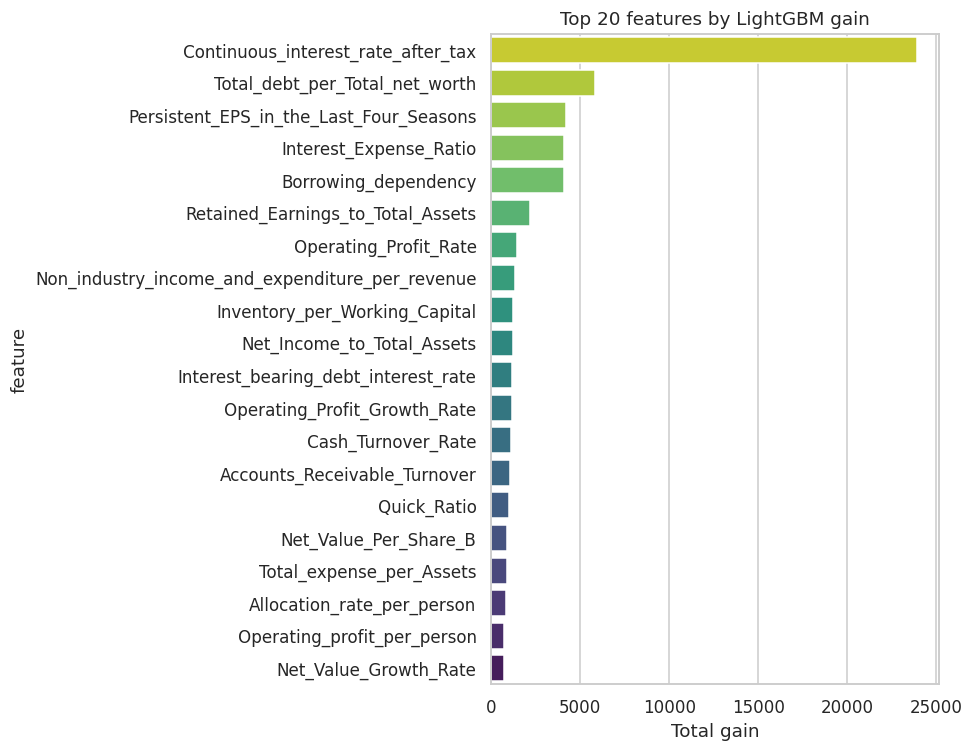

In [31]:
# Feature importance from the fitted LightGBM model
from sklearn.base import clone
shap_model = clone(FINAL_BASE)
shap_model.fit(X_train, y_train)

if hasattr(shap_model, "booster_"):                       # LightGBM: true gain
    gains = shap_model.booster_.feature_importance(importance_type="gain")
else:                                                      # any other tree model
    gains = getattr(shap_model, "feature_importances_", np.zeros(X_train.shape[1]))

importance = (pd.DataFrame({
        "feature": X_train.columns,
        "gain": gains,
    })
    .sort_values("gain", ascending=False)
    .head(20))

plt.figure(figsize=(9, 7))
sns.barplot(data=importance, y="feature", x="gain", hue="feature",
            palette="viridis_r", legend=False)
plt.title("Top 20 features by LightGBM gain")
plt.xlabel("Total gain")
plt.tight_layout()
plt.show()

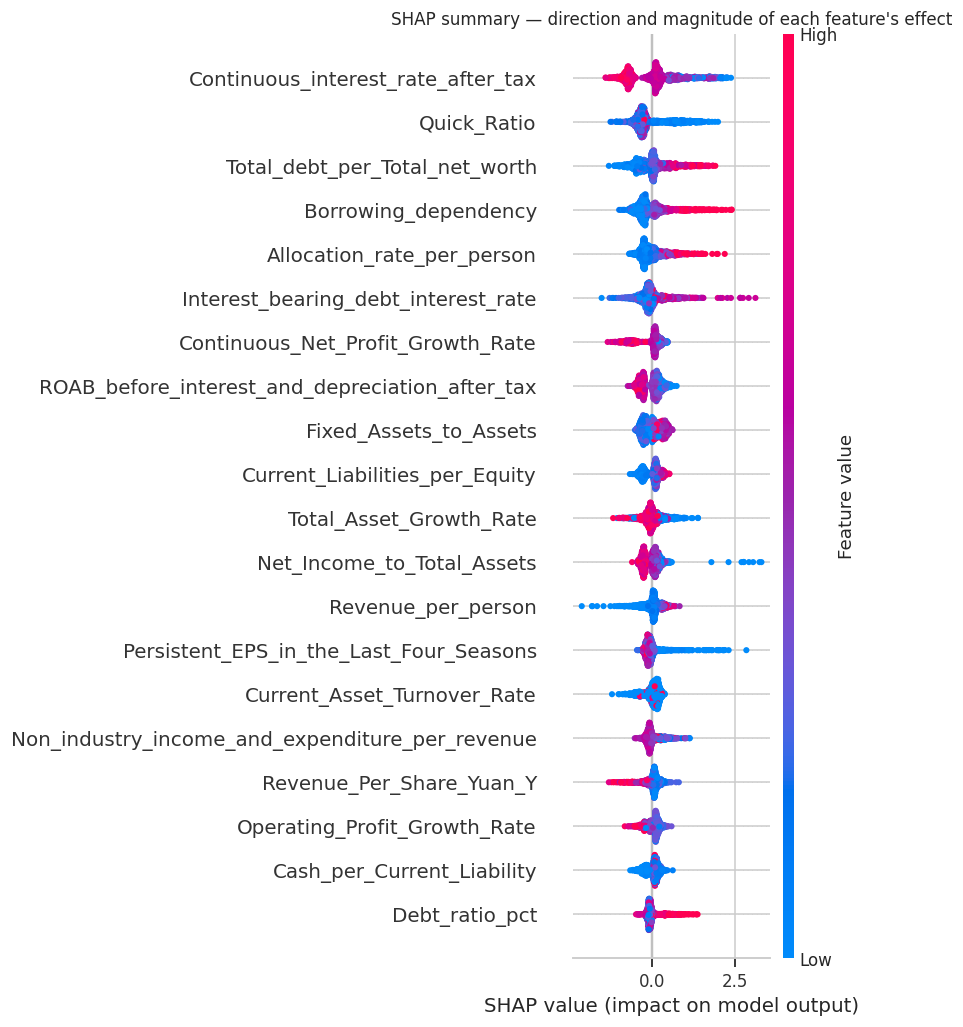

In [32]:
# SHAP values for individual predictions
try:
    import shap
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_test)
    if isinstance(shap_values, list):      # older shap returns one array per class
        shap_values = shap_values[1]

    shap.summary_plot(shap_values, X_test, max_display=20, show=False)
    plt.title("SHAP summary — direction and magnitude of each feature's effect", fontsize=11)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("shap is not installed -- run: pip install shap")
    shap_values = None

Explaining test row 311
  Predicted bankruptcy probability: 0.750
  Actual outcome: BANKRUPT



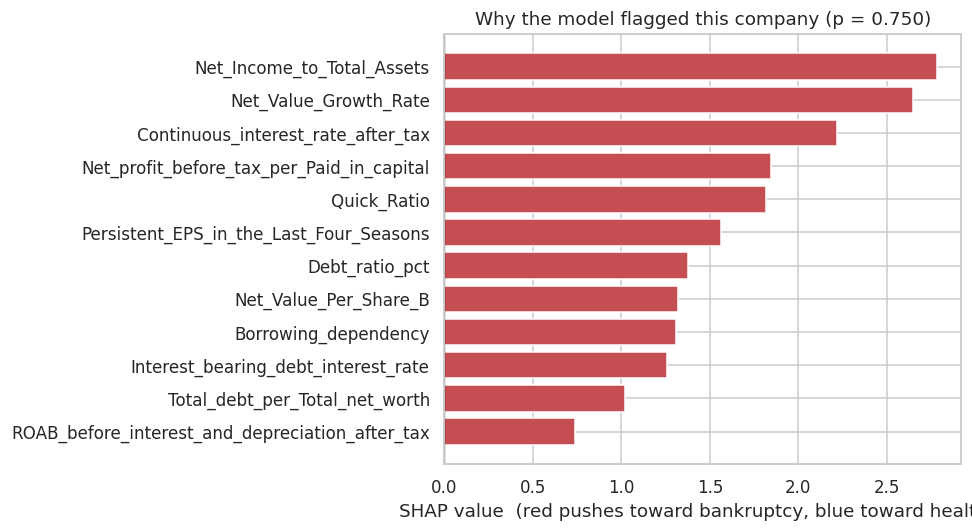

,feature,value,shap
85,Net_Income_to_Total_Assets,0.6610,2.7813
29,Net_Value_Growth_Rate,0.0002,2.6482
9,Continuous_interest_rate_after_tax,0.7811,2.2204
42,Net_profit_before_tax_per_Paid_in_capital,0.0876,1.8477
33,Quick_Ratio,0.0013,1.8162
18,Persistent_EPS_in_the_Last_Four_Seasons,0.1096,1.5642
36,Debt_ratio_pct,0.2887,1.3752
15,Net_Value_Per_Share_B,0.1287,1.3186
39,Borrowing_dependency,0.6690,1.3113
13,Interest_bearing_debt_interest_rate,0.0008,1.2581


In [33]:
# Explain the single highest-risk company in the test set
if shap_values is not None:
    # Explain the single company the model considers most at risk
    idx = int(np.argmax(y_prob))
    print(f"Explaining test row {idx}")
    print(f"  Predicted bankruptcy probability: {y_prob[idx]:.3f}")
    print(f"  Actual outcome: {'BANKRUPT' if y_test.iloc[idx] == 1 else 'healthy'}\n")

    contrib = (pd.DataFrame({
            "feature": X_test.columns,
            "value": X_test.iloc[idx].values,
            "shap": shap_values[idx],
        })
        .assign(abs_shap=lambda d: d["shap"].abs())
        .sort_values("abs_shap", ascending=False)
        .head(12)
        .drop(columns="abs_shap"))

    plt.figure(figsize=(9, 5))
    colors = ["#C44E52" if s > 0 else "#4C72B0" for s in contrib["shap"]]
    plt.barh(contrib["feature"][::-1], contrib["shap"][::-1], color=colors[::-1])
    plt.axvline(0, color="black", lw=0.8)
    plt.xlabel("SHAP value  (red pushes toward bankruptcy, blue toward healthy)")
    plt.title(f"Why the model flagged this company (p = {y_prob[idx]:.3f})")
    plt.tight_layout()
    plt.show()

    display(contrib.round(4))

## 14. Persistence and inference

In [34]:
# Persist the fitted model, threshold, and metadata to disk
import joblib
from datetime import datetime

bundle = {
    "model": final_model,
    "threshold": float(SELECTED_THRESHOLD),
    "feature_names": list(X_train.columns),
    "feature_names_original": FEATURE_NAMES_ORIGINAL,
    "metadata": {
        "created": datetime.now().isoformat(timespec="seconds"),
        "base_estimator": FINAL_LABEL,
        "calibration": "sigmoid (Platt)",
        "threshold_criterion": "median F2-optimal across 3 CV repeats",
        "cost_ratio_FN_to_FP": COST_FN,
        "seed": SEED,
        "train_rows": int(len(X_train)),
        "train_positives": int(y_train.sum()),
        "test_ap": float(test_ap),
        "test_roc_auc": float(test_auc),
        "test_brier": float(test_brier),
        "test_recall": float(threshold_metrics(y_test, y_prob, SELECTED_THRESHOLD)["recall"]),
        "test_precision": float(threshold_metrics(y_test, y_prob, SELECTED_THRESHOLD)["precision"]),
    },
}

model_path = OUT_DIR / "bankruptcy_model.joblib"
joblib.dump(bundle, model_path)
(OUT_DIR / "metadata.json").write_text(json.dumps(bundle["metadata"], indent=2))

print(f"Saved -> {model_path}  ({model_path.stat().st_size / 1e6:.2f} MB)")
print(json.dumps(bundle["metadata"], indent=2))

Saved -> artifacts/bankruptcy_model.joblib  (7.10 MB)
{
  "created": "2026-09-24T08:05:23",
  "base_estimator": "LightGBM (balanced)",
  "calibration": "sigmoid (Platt)",
  "threshold_criterion": "median F2-optimal across 3 CV repeats",
  "cost_ratio_FN_to_FP": 10,
  "seed": 42,
  "train_rows": 5455,
  "train_positives": 176,
  "test_ap": 0.5647989335334477,
  "test_roc_auc": 0.9622589531680441,
  "test_brier": 0.021789213104937557,
  "test_recall": 0.7045454545454546,
  "test_precision": 0.45588235294117646
}


In [35]:
# Inference helper: score new companies with the saved bundle
def predict_bankruptcy_risk(new_data: pd.DataFrame, bundle_path=model_path) -> pd.DataFrame:
    """Score new companies.

    Parameters
    ----------
    new_data : DataFrame with the same financial-ratio columns used in training
               (original or cleaned names both accepted).

    Returns
    -------
    DataFrame with probability, flag, and a coarse risk band.
    """
    b = joblib.load(bundle_path)
    X_new = new_data.copy()
    X_new.columns = clean_names(X_new.columns)

    missing = set(b["feature_names"]) - set(X_new.columns)
    if missing:
        raise ValueError(f"Missing {len(missing)} required feature(s), e.g. {sorted(missing)[:5]}")
    X_new = X_new[b["feature_names"]]

    prob = b["model"].predict_proba(X_new)[:, 1]
    return pd.DataFrame({
        "bankruptcy_probability": prob.round(4),
        "flagged": (prob >= b["threshold"]).astype(int),
        "risk_band": pd.cut(prob,
                            bins=[-0.001, 0.02, b["threshold"], 0.30, 1.0],
                            labels=["Low", "Moderate", "Elevated", "High"]),
    }, index=new_data.index)


# Demo on a held-out slice: 5 of the highest-risk and 5 of the lowest-risk test companies
order = np.argsort(y_prob)
demo_idx = np.concatenate([order[-5:], order[:5]])
demo = predict_bankruptcy_risk(X_test.iloc[demo_idx])
demo["actual"] = y_test.iloc[demo_idx].values
display(demo)

,bankruptcy_probability,flagged,risk_band,actual
3540,0.7297,1,High,0
54,0.7338,1,High,1
2004,0.7447,1,High,1
231,0.7472,1,High,1
2640,0.7496,1,High,1
735,0.0214,0,Moderate,0
5731,0.0214,0,Moderate,0
2895,0.0214,0,Moderate,0
4018,0.0214,0,Moderate,0
2716,0.0214,0,Moderate,0


## 15. Results summary

In [36]:
# Build the results summary table
summary = pd.DataFrame([
    ["Dataset",                f"{len(df):,} companies, {X.shape[1]} features"],
    ["Class balance",          f"{y.mean()*100:.2f}% bankrupt ({int(y.sum())} cases)"],
    ["Final model",            f"{FINAL_LABEL} + Platt calibration"],
    ["Selection metric",       "Average precision (PR-AUC), 5-fold stratified CV"],
    ["Imbalance handling",     "Class weights (resampling strategies also compared)"],
    ["Decision threshold",     f"{SELECTED_THRESHOLD:.4f} (median F2-optimal, OOF)"],
    ["", ""],
    ["Test PR-AUC",            f"{test_ap:.4f}  ({test_ap / y_test.mean():.1f}x random)"],
    ["Test ROC-AUC",           f"{test_auc:.4f}"],
    ["Test Brier score",       f"{test_brier:.4f}"],
    ["Test recall",            f"{threshold_metrics(y_test, y_prob, SELECTED_THRESHOLD)['recall']:.3f}"],
    ["Test precision",         f"{threshold_metrics(y_test, y_prob, SELECTED_THRESHOLD)['precision']:.3f}"],
    ["Bankruptcies caught",    f"{threshold_metrics(y_test, y_prob, SELECTED_THRESHOLD)['TP']} of {int(y_test.sum())}"],
    ["False alarms",           f"{threshold_metrics(y_test, y_prob, SELECTED_THRESHOLD)['FP']} of {int((y_test==0).sum())} healthy"],
], columns=["", ""])

display(summary.style.hide(axis="index").hide(axis="columns"))

Dataset,"6,819 companies, 94 features"
Class balance,3.23% bankrupt (220 cases)
Final model,LightGBM (balanced) + Platt calibration
Selection metric,"Average precision (PR-AUC), 5-fold stratified CV"
Imbalance handling,Class weights (resampling strategies also compared)
Decision threshold,"0.0240 (median F2-optimal, OOF)"
,
Test PR-AUC,0.5648 (17.5x random)
Test ROC-AUC,0.9623
Test Brier score,0.0218
Test recall,0.705
